In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Rastrigin Function
def rastrigin(X):
    x = X[:, 0]
    y = X[:, 1]
    return 20 + (x**2 - 10*np.cos(2*x)) + (y**2 - 10*np.cos(2*y))

In [12]:
# PSO Parameters
num_particles = 30
num_iterations = 100
dimensions = 2
bounds = (-5.12, 5.12)

w = 0.7      
c1 = 1.5     
c2 = 1.5    

In [13]:
positions = np.random.uniform(bounds[0], bounds[1],
                              (num_particles, dimensions))
velocities = np.random.uniform(-1, 1,
                               (num_particles, dimensions))

personal_best_positions = positions.copy()
personal_best_values = rastrigin(positions)

global_best_index = np.argmin(personal_best_values)
global_best_position = personal_best_positions[global_best_index].copy()
global_best_value = personal_best_values[global_best_index]

best_fitness_history = []
mean_fitness_history = []

positions_history = {
    0: positions.copy(),
    20: None,
    "final": None
}

In [14]:
for iteration in range(num_iterations):

    r1 = np.random.rand(num_particles, dimensions)
    r2 = np.random.rand(num_particles, dimensions)

    velocities = (
        w * velocities
        + c1 * r1 * (personal_best_positions - positions)
        + c2 * r2 * (global_best_position - positions)
    )

    positions = positions + velocities
    positions = np.clip(positions, bounds[0], bounds[1])

    fitness = rastrigin(positions)

    improved = fitness < personal_best_values
    personal_best_values[improved] = fitness[improved]
    personal_best_positions[improved] = positions[improved]

    global_best_index = np.argmin(personal_best_values)
    global_best_position = personal_best_positions[global_best_index].copy()
    global_best_value = personal_best_values[global_best_index]

    best_fitness_history.append(global_best_value)
    mean_fitness_history.append(np.mean(fitness))

    if iteration == 20:
        positions_history[20] = positions.copy()

positions_history["final"] = positions.copy()

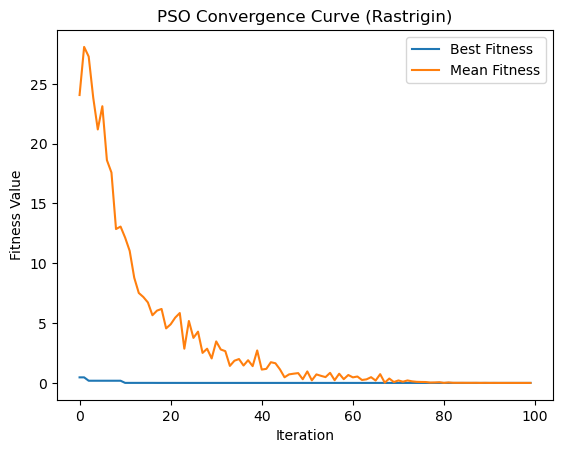

In [15]:
plt.figure()
plt.plot(best_fitness_history, label="Best Fitness")
plt.plot(mean_fitness_history, label="Mean Fitness")
plt.xlabel("Iteration")
plt.ylabel("Fitness Value")
plt.title("PSO Convergence Curve (Rastrigin)")
plt.legend()
plt.show()

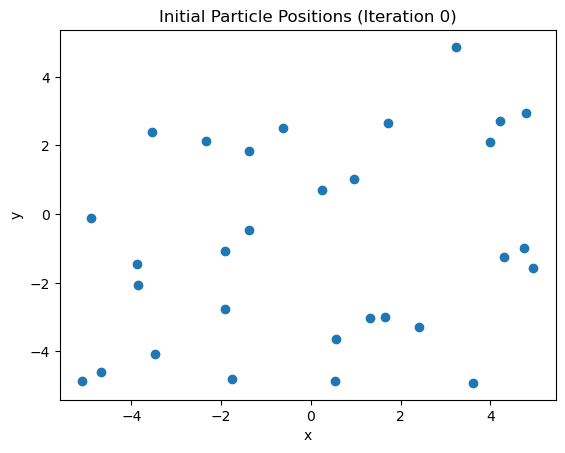

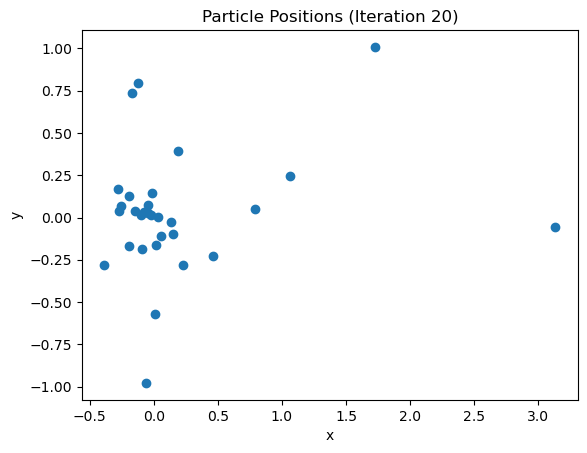

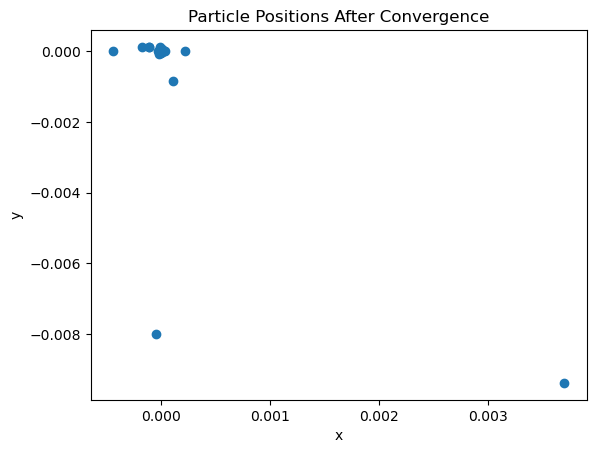

In [16]:
def plot_particles(particles, title):
    plt.figure()
    plt.scatter(particles[:, 0], particles[:, 1])
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.show()

plot_particles(positions_history[0], "Initial Particle Positions (Iteration 0)")
plot_particles(positions_history[20], "Particle Positions (Iteration 20)")
plot_particles(positions_history["final"], "Particle Positions After Convergence")


In [17]:
print("Final global best value:", global_best_value)
print("Final global best position:", global_best_position)

Final global best value: 6.631140081481135e-12
Final global best position: [-5.53859433e-07  9.47261114e-08]


# Effect of Individual and Social Dominant

In [18]:
def PSO(c1, c2, w=0.7,
        num_particles=30,
        num_iterations=100,
        bounds=(-5.12, 5.12)):

    dimensions = 2

    positions = np.random.uniform(bounds[0], bounds[1],
                                  (num_particles, dimensions))
    velocities = np.random.uniform(-1, 1,
                                   (num_particles, dimensions))

    pbest_positions = positions.copy()
    pbest_values = rastrigin(positions)

    gbest_index = np.argmin(pbest_values)
    gbest_position = pbest_positions[gbest_index].copy()
    gbest_value = pbest_values[gbest_index]

    best_history = []
    mean_history = []

    positions_history = {
        0: positions.copy(),
        20: None,
        "final": None
    }

    for iteration in range(num_iterations):

        r1 = np.random.rand(num_particles, dimensions)
        r2 = np.random.rand(num_particles, dimensions)

        velocities = (
            w * velocities
            + c1 * r1 * (pbest_positions - positions)
            + c2 * r2 * (gbest_position - positions)
        )

        positions = positions + velocities
        positions = np.clip(positions, bounds[0], bounds[1])

        fitness = rastrigin(positions)

        improved = fitness < pbest_values
        pbest_values[improved] = fitness[improved]
        pbest_positions[improved] = positions[improved]

        gbest_index = np.argmin(pbest_values)
        gbest_position = pbest_positions[gbest_index].copy()
        gbest_value = pbest_values[gbest_index]

        best_history.append(gbest_value)
        mean_history.append(np.mean(fitness))

        if iteration == 20:
            positions_history[20] = positions.copy()

    positions_history["final"] = positions.copy()

    return gbest_value, gbest_position, best_history, mean_history, positions_history

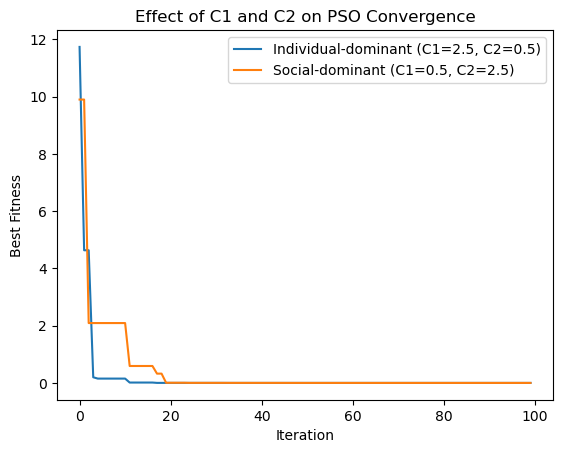

Individual-dominant (C1=2.5, C2=0.5)
  Best value: 4.8682835540603264e-11
  Best position: [ 1.14101584e-06 -1.00813568e-06]
Social-dominant (C1=0.5, C2=2.5)
  Best value: 2.7719593731490022e-08
  Best position: [3.59424281e-05 5.30307339e-06]


In [19]:
configs = [
    {"c1": 2.5, "c2": 0.5, "label": "Individual-dominant (C1=2.5, C2=0.5)"},
    {"c1": 0.5, "c2": 2.5, "label": "Social-dominant (C1=0.5, C2=2.5)"}
]

results = {}

for cfg in configs:
    gbest_val, gbest_pos, best_hist, mean_hist, pos_hist = PSO(
        c1=cfg["c1"],
        c2=cfg["c2"]
    )
    results[cfg["label"]] = {
        "best_value": gbest_val,
        "best_position": gbest_pos,
        "best_history": best_hist,
        "mean_history": mean_hist,
        "positions_history": pos_hist
    }


plt.figure()
for label, res in results.items():
    plt.plot(res["best_history"], label=label)

plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("Effect of C1 and C2 on PSO Convergence")
plt.legend()
plt.show()

for label, res in results.items():
    print(label)
    print("  Best value:", res["best_value"])
    print("  Best position:", res["best_position"])